<a href="https://colab.research.google.com/github/apranav22/bayesian_nmor/blob/main/toy_bayesian_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

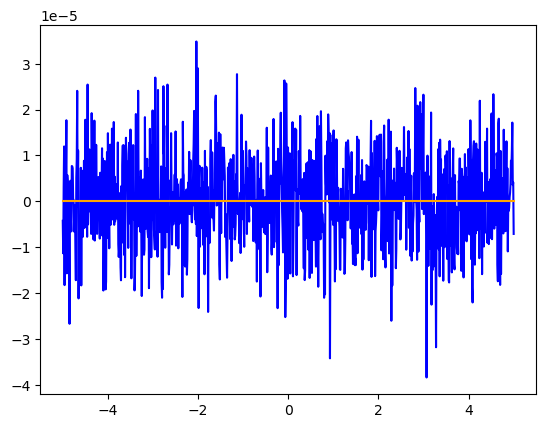

In [21]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

global tou, delta, k2, transit_rate, lo

# spontaneous emission rate ~ 10^7 Hz
tou = 10**7
# detuning
delta = 0.5 * tou
# saturation parameter
k2 = 5
# transit rate
transit_rate = 0.01 * tou
# unsaturated absorption length
lo = 0.001


def alpha_th(B_tot):
    # gyromagnetic ratio ~ 10^6 Hz/Guass, larmor freq
    gyro = 0.00001
    omega_l = gyro * (B_tot)
    D = (
        8
        * (omega_l**2)
        * (
            (32 * (tou**2) * (k2 + 3) * ((omega_l**2) + (delta**2)))
            + (192 * (((delta**2) - (omega_l**2)) ** 2))
            + ((tou**4) * (k2 + 2) * (k2 + 6))
        )
    ) + (
        2
        * (transit_rate**2)
        * (((tou**2) * ((2 * k2) + 3)) + (12 * (delta**2)))
        * (((tou**2) * ((k2 + 2) ** 2)) + (16 * (delta**2)))
    )
    alpha_th = (
        -6
        * tou
        * omega_l
        * (
            (
                8
                * (omega_l**2)
                * ((8 * (omega_l**2)) + ((tou**2) * (k2 + 2)) - (8 * (delta**2)))
            )
            + (
                transit_rate
                * (
                    (4 * transit_rate * ((tou**2) - ((2 * delta) ** 2)))
                    - ((tou**3) * k2 * (k2 + 2))
                )
            )
        )
        / D
    )
    return lo * alpha_th


def alpha_exp(alpha_th, sigma):
    return lo * (alpha_th + np.random.normal(0, sigma, size=alpha_th.shape))


# Dispersive Lorentzian Model
"""def alpha_th(B_total, Gamma=1.0):
    # Simplified dispersive Lorentzian form
    return B_total / (B_total**2 + Gamma**2)"""


B_unk = 0.4
gamma = 0.02
sigma = 0.01

B_bias = np.linspace(-5, 5, 1000)
B_tot = B_unk + B_bias

alpha_vals = alpha_th(B_tot)


alpha_exp_vals = alpha_exp(alpha_vals, sigma)
plt.figure()
plt.plot(B_bias, alpha_exp_vals, color="blue")
plt.plot(B_bias, alpha_vals, color="orange")

In [22]:
import numpy as np
import cupy as cp
from scipy.stats import norm
from scipy.integrate import simpson
import os

global tou, delta, k2, transit_rate, lo
# spontaneous emission rate
tou = 1
# detuning
delta = 0.1
# saturation parameter
k2 = 5
# transit rate
transit_rate = 0.01 * tou
# unsaturated absorption length
lo = 1


def alpha_theory(B_tot):
    # gyromagnetic ratio, larmor freq
    gyro = 1
    omega_l = gyro * (B_tot)
    D = (
        8
        * (omega_l**2)
        * (
            (32 * (tou**2) * (k2 + 3) * ((omega_l**2) + (delta**2)))
            + (192 * (((delta**2) - (omega_l**2)) ** 2))
            + ((tou**4) * (k2 + 2) * (k2 + 6))
        )
    ) + (
        2
        * (transit_rate**2)
        * (((tou**2) * ((2 * k2) + 3)) + (12 * (delta**2)))
        * (((tou**2) * ((k2 + 2) ** 2)) + (16 * (delta**2)))
    )
    alpha_th = (
        -6
        * tou
        * omega_l
        * (
            (
                8
                * (omega_l**2)
                * ((8 * (omega_l**2)) + ((tou**2) * (k2 + 2)) - (8 * (delta**2)))
            )
            + (
                transit_rate
                * (
                    (4 * transit_rate * ((tou**2) - ((2 * delta) ** 2)))
                    - ((tou**3) * k2 * (k2 + 2))
                )
            )
        )
        / D
        / lo
    )
    return alpha_th


"""# Dispersive Lorentzian Model
def alpha_theory(B_total, Gamma=1.0):
    # Simplified dispersive Lorentzian form
    return B_total / (B_total**2 + Gamma**2)"""


# Likelihood for a measurement
"""def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05, Gamma=1.0):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total, Gamma)
    return norm.pdf(alpha_meas, loc=alpha_exp, scale=sigma)"""


# likelihood for cp and also actual expression
def likelihood(alpha_meas, B_unknown, B_bias, sigma=0.05, Gamma=1.0):
    B_total = B_unknown + B_bias
    alpha_exp = alpha_theory(B_total)
    prefactor = 1.0 / (sigma * cp.sqrt(2 * np.pi))
    exponent = -((alpha_meas - alpha_exp) ** 2) / (2 * sigma**2)

    return prefactor * cp.exp(exponent)

def simpson_old(y, x):
    """Vectorized Simpson's rule over the last axis for CuPy arrays."""
    dx = x[1] - x[0]
    n = y.shape[-1]
    # If even number of intervals, drop the last point to make it odd
    if n % 2 == 0:
        y = y[..., :-1]
        x = x[:-1]
        n = n - 1
    # Simpson weights: 1, 4, 2, 4, ..., 2, 4, 1
    w = cp.ones(n, dtype=y.dtype)
    w[1:-1:2] = 4
    w[2:-1:2] = 2
    return (dx / 3.0) * cp.sum(y * w, axis=-1)

def simpson_gpu(y, x):
    """Vectorized Simpson's rule over the last axis for CuPy arrays."""
    dx = x[1] - x[0]
    n = y.shape[-1]
    # If even number of intervals, drop the last point to make it odd
    if n % 2 == 0:
        y = y[..., :-1]
        x = x[:-1]
        n = n - 1
    # Simpson weights: 1, 4, 2, 4, ..., 2, 4, 1
    w = cp.ones(n, dtype=y.dtype)
    w[1:-1:2] = 4
    w[2:-1:2] = 2
    return (dx / 3.0) * cp.sum(y * w, axis=-1)


def expected_KL(alpha_meas_bias, prior, B_grid, sigma=0.1, n_samples=100):
    """Original scalar-candidate version (kept for reference)."""
    alphas = cp.linspace(-1.5, 1.5, n_samples)

    alpha_grid, B_grid_2d = cp.meshgrid(alphas, B_grid, indexing="ij")
    L_matrix = likelihood(alpha_grid, B_grid_2d, alpha_meas_bias, sigma)

    integrand_P_alpha = L_matrix * prior
    P_alpha = simpson_gpu(integrand_P_alpha, B_grid)

    norm_factors = P_alpha
    valid_indices = norm_factors > 1e-15
    if not cp.any(valid_indices):
        return 0.0

    epsilon = 1e-15
    post_matrix = integrand_P_alpha[valid_indices] / (
        norm_factors[valid_indices, cp.newaxis] + epsilon
    )

    ratio = post_matrix / (prior[cp.newaxis, :] + epsilon)
    ratio = cp.maximum(ratio, epsilon)

    KL_vals = simpson_gpu(post_matrix * cp.log(ratio), B_grid)

    expected_KL_val = cp.sum(P_alpha[valid_indices] * KL_vals) / (
        cp.sum(P_alpha[valid_indices]) + epsilon
    )

    return float(expected_KL_val)


def expected_KL_batched(
    candidates,
    prior,
    B_grid,
    sigma=0.1,
    n_samples=100,
    alpha_min=-1.5,
    alpha_max=1.5,
    batch_size=512,
    epsilon=1e-15,
    alpha_exp_all=None,
):
    """Compute Expected KL for many B_bias candidates in GPU batches.

    Shapes:
    - candidates: (C,)
    - prior: (G,)
    - B_grid: (G,)
    - alpha_exp_all (optional): (C,G) precomputed alpha_theory(B_grid + candidate)

    Returns: (C,) CuPy array of expected KL values.
    """
    candidates = cp.asarray(candidates)
    prior = cp.asarray(prior)
    B_grid = cp.asarray(B_grid)

    alphas = cp.linspace(alpha_min, alpha_max, int(n_samples), dtype=prior.dtype)
    C = candidates.shape[0]
    out = cp.empty((C,), dtype=prior.dtype)

    # Broadcast helpers
    alpha_grid = alphas[:, cp.newaxis, cp.newaxis]  # (A,1,1)
    prior_expanded = prior[cp.newaxis, cp.newaxis, :]  # (1,1,G)

    # Precomputed alpha_exp_all expected shape: (C,G)
    if alpha_exp_all is not None:
        alpha_exp_all = cp.asarray(alpha_exp_all)
        assert alpha_exp_all.shape == (C, B_grid.shape[0])

    for start in range(0, C, int(batch_size)):
        end = min(start + int(batch_size), C)
        cand_batch = candidates[start:end]  # (B,)

        if alpha_exp_all is None:
            # Compute on the fly for this batch: (1,B,G)
            alpha_exp = alpha_theory(
                cand_batch[cp.newaxis, :, cp.newaxis]
                + B_grid[cp.newaxis, cp.newaxis, :]
            )
        else:
            # Reuse precomputed: (1,B,G)
            alpha_exp = alpha_exp_all[start:end][cp.newaxis, :, :]

        pref = 1.0 / (sigma * cp.sqrt(2 * np.pi))
        L = pref * cp.exp(-((alpha_grid - alpha_exp) ** 2) / (2 * sigma**2))  # (A,B,G)

        integrand = L * prior_expanded  # (A,B,G)
        P_alpha = simpson_gpu(integrand, B_grid)  # (A,B)

        # Posterior over B given alpha
        post = integrand / (P_alpha[:, :, cp.newaxis] + epsilon)  # (A,B,G)

        ratio = post / (prior_expanded + epsilon)
        ratio = cp.maximum(ratio, epsilon)

        KL_integrand = post * cp.log(ratio)  # (A,B,G)
        KL_vals = simpson_gpu(KL_integrand, B_grid)  # (A,B)

        # Weighted average over alpha
        num = cp.sum(KL_vals * P_alpha, axis=0)  # (B,)
        den = cp.sum(P_alpha, axis=0) + epsilon  # (B,)
        out[start:end] = num / den

        # Free intermediates early
        del L, integrand, P_alpha, post, ratio, KL_integrand, KL_vals, alpha_exp

    return out


# Posterior update
def update_posterior(prior, measurements, B_grid, B_bias, sigma=0.05):
    post = prior.copy()
    for alpha_meas in measurements:
        # Calculate likelihood for all B_grid points at once
        L = likelihood(alpha_meas, B_grid, B_bias, sigma)
        post *= L

    # normalize
    post_sum = simpson_gpu(post, B_grid)
    if post_sum > 1e-12:
        post /= post_sum
    else:
        # Handle cases where the posterior is effectively zero everywhere
        post = cp.ones_like(B_grid) / (B_grid.max() - B_grid.min())
    return post


# Adaptive Bayesian Experiment Loop
def run_experiment(
    N_exp=5,
    B_true=0.2,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=1000,
    candidates=cp.linspace(-1, 1, 5000),
    Test=0,
    Gamma=1.0,
    kl_n_samples=128,
    kl_batch_size=512,
    precompute_alpha=True,
):  # Computes candidate utilities on GPU in batches
    # Step 1: initialize prior
    B_grid = cp.linspace(B_range[0], B_range[1], int(n_grid))
    prior = cp.ones_like(B_grid) / (B_range[1] - B_range[0])  # uniform prior

    # Ensure candidates on GPU
    candidates = cp.asarray(candidates)

    # Optional: precompute alpha_theory(B_grid + candidate) for all candidates once
    alpha_exp_all = None
    if precompute_alpha:
        # Shape: (C,G)
        alpha_exp_all = alpha_theory(candidates[:, cp.newaxis] + B_grid[cp.newaxis, :])

    B_biases = []
    Expected_KL = []
    posteriors = [prior]

    # Safe, cross-platform output dir
    base_dir = os.path.join("experiments", f"Test_{Test}")
    os.makedirs(base_dir, exist_ok=True)

    for i in range(N_exp):
        # Step 2: choose bias by maximizing expected KL using batched GPU eval
        util_vals = expected_KL_batched(
            candidates,
            prior,
            B_grid,
            sigma=sigma,
            n_samples=kl_n_samples,
            alpha_min=-1.5,
            alpha_max=1.5,
            batch_size=kl_batch_size,
            alpha_exp_all=alpha_exp_all,
        )
        best_idx = int(cp.argmax(util_vals).get())
        B_bias = float(candidates[best_idx].get())
        B_biases.append(B_bias)
        Expected_KL.append(float(util_vals[best_idx].get()))

        # Save diagnostic plot (convert to CPU for matplotlib)
        try:
            import matplotlib.pyplot as plt

            save_path = os.path.join(
                base_dir, f"Expected_KL_vs_B_bias_Experiment_{i + 1}.png"
            )
            plt.figure(figsize=(6, 4))
            plt.plot(
                cp.asnumpy(candidates),
                cp.asnumpy(util_vals),
                label="Expected KL vs B_bias",
            )
            plt.xlabel("B_bias")
            plt.ylabel("Expected KL Divergence")
            plt.title(f"Expected KL vs B_bias for Experiment {i + 1}")
            plt.tight_layout()
            plt.savefig(save_path)
            plt.close()
        except Exception:
            pass

        # Step 3: generate synthetic measurement
        B_total = B_true + B_bias
        alpha_true = alpha_theory(B_total)
        alpha_meas = cp.random.normal(
            alpha_true, sigma, size=5
        )  # 5 samples -> Integration time

        # Step 4: update posterior
        posterior = update_posterior(prior, alpha_meas, B_grid, B_bias, sigma)
        posteriors.append(posterior)
        prior = posterior

    final_posteriors_cpu = [p.get() for p in posteriors]
    final_biases_cpu = B_biases
    final_B_grid = B_grid.get()

    return final_B_grid, final_posteriors_cpu, final_biases_cpu, Expected_KL


def calculate_summary_stats(posterior, B_grid):
    # Mean
    mean = simpson(B_grid * posterior, B_grid)

    # Mode
    mode_index = np.argmax(posterior)
    mode = B_grid[mode_index]

    # Variance
    variance = simpson(((B_grid - mean) ** 2) * posterior, B_grid)

    return mean, mode, variance

Test 0

Final posterior area (should be ~1): 1.000000


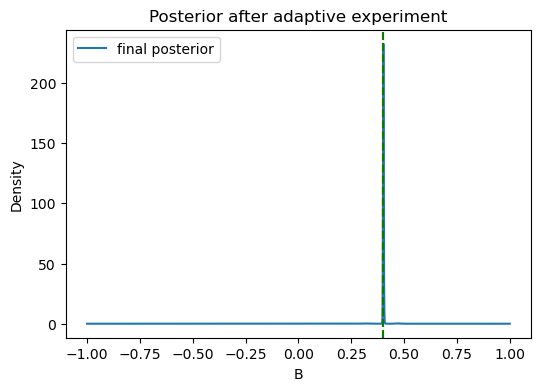

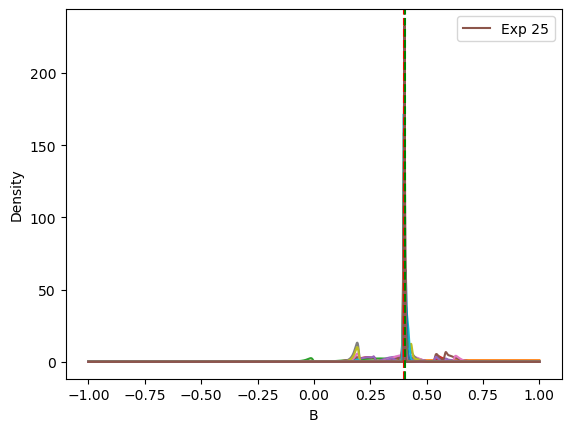

Mean: 0.40191806340888425 , Mode: 0.40188037607521504 , Varianc: 0.00012344217836099714
0.00020004000800160314 : 0.21824828643661637 

-0.5343068613722745 : 0.1179612574672695 

-0.26865373074614923 : 0.08774772626639017 

-0.5819163832766553 : 0.07246638693565371 

-0.20464092818563712 : 0.06310951048804579 

-0.6203240648129625 : 0.07213543127768246 

-0.395879175835167 : 0.06993734238640989 

-0.4330866173234647 : 0.0977986385790508 

-0.4242848569713943 : 0.09204760613906746 

-0.4118823764752951 : 0.07099259022899782 

-0.40548109621924383 : 0.04860686586922421 

-0.3870774154830966 : 0.047919709415611945 

-0.40028005601120226 : 0.03709234129962969 

-0.3854770954190838 : 0.036482646701407495 

-0.38387677535507103 : 0.05983071209969301 

-0.3986797359471894 : 0.03343914188717572 

-0.40108021604320865 : 0.025638050372924784 

-0.40028005601120226 : 0.02110734852714513 

-0.397879575915183 : 0.019118252152872602 

-0.397879575915183 : 0.016508417588131263 

-0.40028005601120226 :

In [23]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=25,
    B_true=B_true,
    sigma=0.2,
    B_range=(-1, 1),
    n_grid=5000,
    candidates=cp.linspace(-1, 1, 5000),
    Test=0,
    Gamma=0.01,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

Test 1

Final posterior area (should be ~1): 1.000000


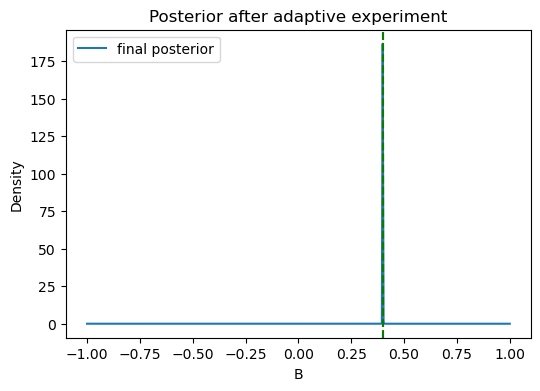

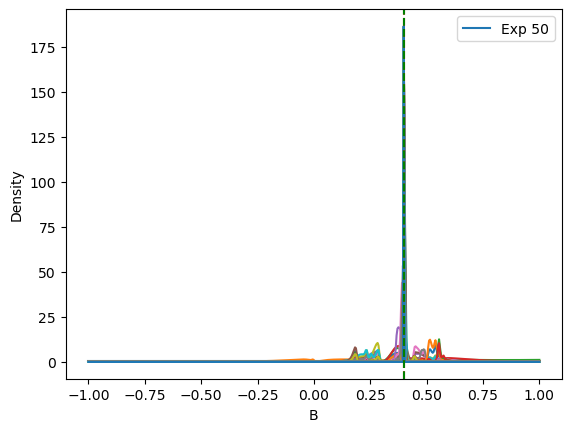

Mean: 0.3988098519469056 , Mode: 0.39879759519038066 , Varianc: 1.84714978010712e-07
0.002004008016031981 : 0.2199545885284854 

-0.29058116232464937 : 0.15256642043261284 

-0.5390781563126252 : 0.11937233049817166 

-0.4428857715430862 : 0.0840283940282184 

-0.23446893787575157 : 0.0781781114416909 

-0.49098196392785576 : 0.07246434342619343 

-0.47494989979959923 : 0.06787957851834703 

-0.5030060120240482 : 0.06434668280739694 

-0.25450901803607223 : 0.0696748607370239 

-0.19438877755511028 : 0.06173526394433974 

-0.5551102204408818 : 0.08419728072076163 

-0.5470941883767535 : 0.07179237187680988 

-0.5751503006012024 : 0.07363289521483254 

-0.36272545090180364 : 0.06900973008483981 

-0.38677354709418843 : 0.08111409326079572 

-0.4068136272545091 : 0.0849525155196053 

-0.3947895791583167 : 0.06444169525785176 

-0.3987975951903808 : 0.05310469541718529 

-0.41883767535070143 : 0.07282931548304085 

-0.40280561122244496 : 0.04180635986586236 

-0.3987975951903808 : 0.02982

In [24]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=50,
    B_true=B_true,
    sigma=0.2,
    B_range=(-1, 1),
    n_grid=500,
    candidates=cp.linspace(-1, 1, 500),
    Test=1,
    Gamma=0.01,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

Test 3

Final posterior area (should be ~1): 1.000000


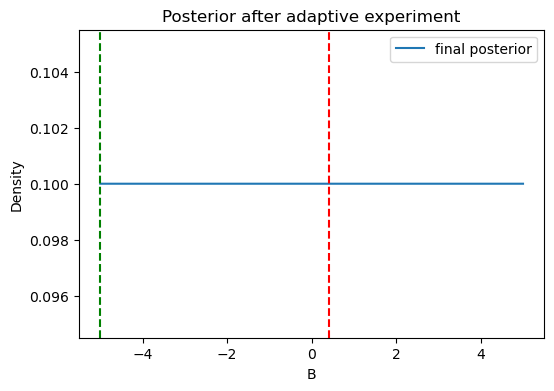

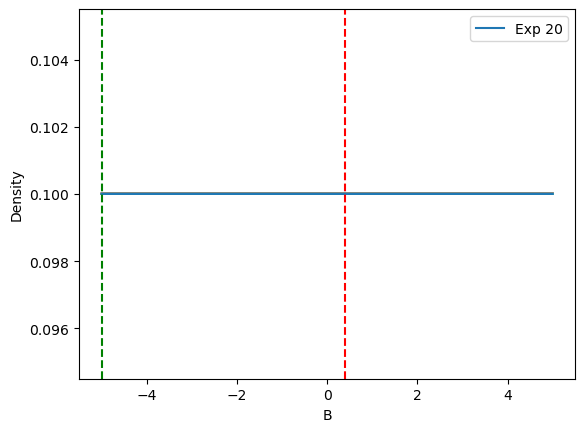

Mean: -1.240327285323417e-16 , Mode: -5.0 , Varianc: 8.333333333333334
-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 

-5.0 



In [25]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0,
    B_range=(-5, 5),
    n_grid=5000,
    candidates=cp.linspace(-5, 5, 5000),
    Test=3,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

Test 4

Final posterior area (should be ~1): 1.000000


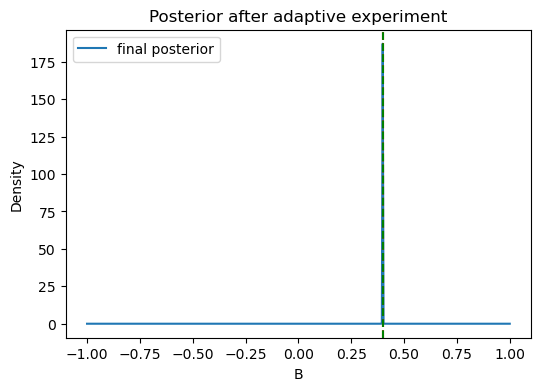

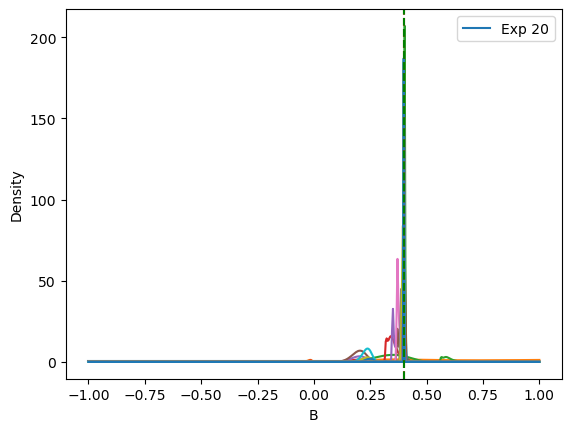

Mean: 0.39879572587700857 , Mode: 0.39879759519038066 , Varianc: 8.866003373756849e-08
0.002004008016031981 : 0.5480524201616753 

-0.5591182364729459 : 0.34817518739033065 

-0.3146292585170341 : 0.20199818674367978 

-0.34669338677354716 : 0.26869275956531596 

-0.36673346693386777 : 0.2795299226222082 

-0.4068136272545091 : 0.25910939867594 

-0.3827655310621243 : 0.289561472855974 

-0.3947895791583167 : 0.2601884953805044 

-0.3987975951903808 : 0.17224670612928936 

-0.4148296593186373 : 0.2895848758377517 

-0.4068136272545091 : 0.1174029292377047 

-0.3987975951903808 : 0.05063571354289729 

-0.40280561122244496 : 0.05359322006571155 

-0.3987975951903808 : 0.030649072934438814 

-0.3987975951903808 : 0.006433269240371826 

-0.3987975951903808 : 0.00345360613758301 

-0.3947895791583167 : 0.003297426253916677 

-0.3947895791583167 : 0.0020074545497923485 

-0.3987975951903808 : 0.0005460375618526556 

-0.3987975951903808 : 9.125413190842393e-05 



In [26]:
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases, xpected_kl = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.1,
    B_range=(-1, 1),
    n_grid=500,
    candidates=cp.linspace(-1, 1, 500),
    Test=4,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for i in range(len(biases)):
    print(biases[i], ":", xpected_kl[i], "\n")

Test 5

In [27]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=5000,
    candidates=cp.linspace(-1, 1, 5000),
    Test=5,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

ValueError: too many values to unpack (expected 3)

  Test 6

In [ ]:
# @title
# Run adaptive Bayesian experiment from module
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.integrate import simpson

B_true = 0.4
B_grid, posteriors, biases = run_experiment(
    N_exp=20,
    B_true=B_true,
    Gamma=1.0,
    sigma=0.05,
    B_range=(-1, 1),
    n_grid=500,
    candidates=cp.linspace(-1, 1, 500),
    Test=6,
)
# Plot final posterior and show chosen biases


final_posterior = posteriors[-1]
area = simpson(final_posterior, B_grid)
print(f"Final posterior area (should be ~1): {area:.6f}")

plt.figure(figsize=(6, 4))
plt.plot(B_grid, final_posterior, label="final posterior")
plt.xlabel("B")
plt.ylabel("Density")
plt.title("Posterior after adaptive experiment")
plt.legend()
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()


for i in range(len(posteriors)):
    line = plt.plot(B_grid, posteriors[i], label=f"Exp {i}")
    if i >= len(posteriors) - 5:
        plt.legend(handles=line)
plt.xlabel("B")
plt.ylabel("Density")
plt.axvline(0.4, color="red", linestyle="--", label="True B")
plt.axvline(
    B_grid[np.argmax(final_posterior)],
    color="green",
    linestyle="--",
    label="MAP Estimate",
)
plt.show()

mean_final, mode_final, variance_final = calculate_summary_stats(
    final_posterior, B_grid
)
print("Mean:", mean_final, ", Mode:", mode_final, ", Varianc:", variance_final)
for b in biases:
    print(b, "\n")

In [ ]:
# TODO: compare with frequentist zero crossing approach: give quantitative estimate of:
# 1. amount of readings required for both
# 2. accuracy of estimate for both
# 3. inference time for both

# TODO
# 1. clean up matplotlib rendering and check for redundance
# 2. interpretability
# 3. adaptive simpson
# 4. mcmc
# 5. float64->float32
# 6. adaptive grid refinememtn
# 7. vectorisation of likelihood 


In [ ]:
# Quick GPU smoke test for expected_KL_batched (keeps work small)
import cupy as cp

# Small grids to keep it fast
B_grid_sm = cp.linspace(-1, 1, 257)
prior_sm = cp.ones_like(B_grid_sm) / (B_grid_sm[-1] - B_grid_sm[0])
candidates_sm = cp.linspace(-1, 1, 64)

utils_sm = expected_KL_batched(
    candidates_sm,
    prior_sm,
    B_grid_sm,
    sigma=0.1,
    n_samples=16,
    batch_size=32,
)

print("Smoke util len:", utils_sm.shape[0])
print("Best cand idx:", int(cp.argmax(utils_sm).get()))
print("Max util:", float(utils_sm.max().get()))

Smoke util len: 64
Best cand idx: 31
Max util: 0.543902519004818
